In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

In [3]:
train_dir= "D:\Data Science\Campusx\Cats vs Dogs\Train"
test_dir= "D:\Data Science\Campusx\Cats vs Dogs\Test"

In [4]:
from keras import utils

In [5]:
train_data= utils.image_dataset_from_directory(
    train_dir,
    image_size=(256,256),
    batch_size=32,
    label_mode="int",
    labels="inferred"
)

Found 791 files belonging to 2 classes.


In [6]:
test_data= utils.image_dataset_from_directory(
    test_dir,
    image_size=(256,256),
    batch_size=32,
    labels="inferred",
    label_mode="int",   
)

Found 209 files belonging to 2 classes.


In [7]:
def process(image, label):
    image= tf.cast(image/255, tf.float64)
    return image,label

In [8]:
train_data= train_data.map(process)
test_data= test_data.map(process)

In [9]:
from keras.layers import Dense, Flatten, Input, Conv2D, MaxPooling2D, Dropout, BatchNormalization
from keras.regularizers import L2
from keras.models import Sequential
from keras.callbacks import EarlyStopping

In [10]:
model= Sequential([
    Input(shape=(256,256,3)),
    Conv2D(32, kernel_size=(3,3), padding="valid", strides=(1,1), activation="relu"),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2), padding="valid", strides=2),

    Conv2D(64, kernel_size=(3,3), padding="valid", strides=(1,1), activation="relu"),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2), strides=2, padding="valid"),

    Conv2D(128, kernel_size=(3,3), padding="valid", strides=(1,1), activation="relu"),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2), strides=2, padding="valid"),

    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(64, activation="relu"),
    # Dropout(0.4),
    Dense(32, activation="relu"),
    # Dropout(0.3),
    Dense(16, activation="relu"),
    # Dropout(0.3),
    Dense(8, activation="relu"),
    Dense(4, activation="relu"),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,850,913 (56.65 MB)

 Trainable params: 14,850,465 (56.65 MB)

 Non-trainable params: 448 (1.75 KB)

In [12]:
model.compile(
    optimizer="Adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [13]:
callback= EarlyStopping(
    monitor="val_loss",
    min_delta=0.0001,
    mode="auto",
    patience=5,
    baseline=None,
    restore_best_weights=False,
    verbose=1
)

In [14]:
history= model.fit(train_data, epochs=200, callbacks=callback, validation_data=test_data)

Epoch 1/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.5247 - loss: 1.3711 - val_accuracy: 0.5742 - val_loss: 0.6876
Epoch 2/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.5790 - loss: 0.7434 - val_accuracy: 0.5598 - val_loss: 0.9524
Epoch 3/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.6397 - loss: 0.6345 - val_accuracy: 0.5502 - val_loss: 0.6861
Epoch 4/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.6991 - loss: 0.5646 - val_accuracy: 0.4833 - val_loss: 0.6860
Epoch 5/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.6877 - loss: 0.6032 - val_accuracy: 0.5120 - val_loss: 0.6407
Epoch 6/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.7762 - loss: 0.5375 - val_accuracy: 0.7033 - val_loss: 0.5734
Epoch 7/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.7484 - loss: 0.5543 - val_accuracy: 0.6890 - val_loss: 0.5728
Epoch 8/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.8180 - loss: 0.4086 - val_accuracy: 0.7512 - v

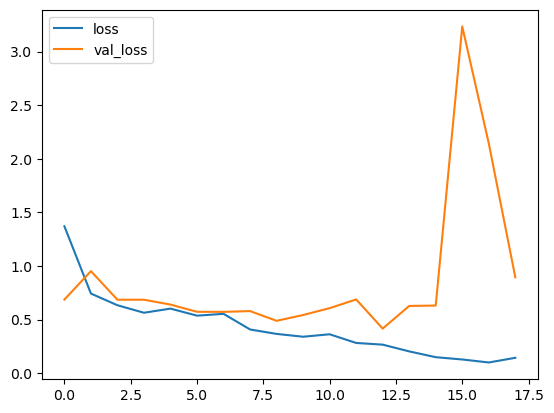

In [15]:
plt.plot(history.history["loss"], label="loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.legend()

In [16]:
predictions= model.predict(test_data)

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 227ms/step


In [17]:
predictions= predictions.ravel()

In [18]:
def results(predictions):
    for i in range(len(predictions)):
        if predictions[i]>=0.5:
            predictions[i]=1
        else:
            predictions[i]=0
    return predictions

In [19]:
predictions= results(predictions)

In [20]:
predictions

array([0., 0., 1., 0., 1., 1., 0., 0., 1., 1., 1., 0., 1., 0., 1., 0., 1.,
       0., 0., 0., 0., 0., 1., 0., 1., 1., 0., 1., 1., 0., 0., 0., 1., 1.,
       0., 0., 1., 0., 1., 0., 0., 1., 0., 0., 1., 0., 0., 1., 0., 1., 0.,
       1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 1., 1., 0., 0., 1.,
       1., 0., 0., 0., 0., 0., 1., 0., 1., 0., 1., 0., 0., 0., 1., 0., 0.,
       0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 1., 1., 0., 0., 0., 0., 0.,
       0., 1., 0., 0., 0., 0., 1., 0., 1., 1., 0., 0., 0., 1., 0., 0., 0.,
       0., 0., 1., 0., 0., 0., 1., 0., 1., 0., 0., 0., 1., 0., 1., 0., 0.,
       0., 0., 1., 1., 0., 0., 0., 0., 0., 1., 0., 1., 0., 0., 0., 0., 1.,
       1., 0., 0., 0., 0., 0., 1., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0.,
       1., 0., 0., 0., 1., 0., 1., 1., 1., 1., 0., 0., 1., 1., 0., 0., 1.,
       0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 1., 0., 0., 0.,
       1., 1., 0., 0., 1.], dtype=float32)

In [21]:
test_loss, test_acc= model.evaluate(test_data)

2/7 ━━━━━━━━━━━━━━━━━━━━ 1s 203ms/step - accuracy: 0.8438 - loss: 0.9642

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 192ms/step - accuracy: 0.8852 - loss: 0.8954


In [22]:
print(f"Test loss:{test_loss}")
print(f"Test_accuracy:{test_acc}")

Test loss:0.8954333662986755
Test_accuracy:0.8851674795150757
